In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('Data_netflix.csv', lineterminator='\n')

In [3]:
df.head(5)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.info()
#basic info of data set

<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9827 non-null   str    
 8   Poster_Url         9827 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 691.1 KB


In [5]:
df['Genre'].head(5)
#to see the first 5 values of genre column

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: str

In [6]:
df.duplicated().sum()
#checking for sum of duplicate values in the dataset

np.int64(0)

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9822    False
9823    False
9824    False
9825    False
9826    False
Length: 9827, dtype: bool

In [8]:
df.describe()
#describe function gives the statistical summary of the dataset

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


##### Format the date and time
###### 1 Convert release date column to datetime format from string format
###### 2 Convert release date column to year only

In [9]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
#Changing the datatype of Release_Date column to datetime format

print(df['Release_Date'].dtypes)
#checking the datatype of Release_Date column after changing it to datetime format

datetime64[us]


In [10]:
df['Release_Date'] = df['Release_Date'].dt.year
#converting the Release_Date column to year format

df['Release_Date'].dtypes
#checking the datatype of Release_Date column after changing it to year format

dtype('int32')

In [11]:
df.head(5)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


##### Dropping the unnecessary columns from the dataset 

In [12]:
cols = ['Overview','Original_Language','Poster_Url']
#Picking the columns which are not required for analysis

In [13]:
df.drop(cols, axis = 1, inplace = True)
#Dropping the columns cols
#axis=1: Tells pandas to look at the columns instead of the rows. (axis=0 targets rows)
#inplace=True: Modifies the original DataFrame directly.

df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='str')

In [14]:
df.head(5)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


##### Categorise average rating column in 4 : Popular, Avg, Below_Avg, Not_popular

In [15]:
#We will make user defined functions with name categorize_col to make the analysis easier and more efficient.
#We will put data in the same so we used df
#we will need column so we use col
#We need to label them so we will use labels

def categorize_col(df, col, labels):

    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    #edges are the function which will be used to categorize the data into different bins.
    #df is our data frame
    #col is the column which we want to categorize

    df[col] = pd.cut(df[col], edges, labels=labels, duplicates='drop')
    #df ke col ko categorize karne ke liye pd.cut function ka use kiya gaya hai.
    #df[col] ke andar edges vali categories ke hisaab se label karenge labels=labels.
    #duplicates='drop' ka use kiya gaya hai taki agar koi duplicate value ho to usko drop kar de.

    return df

In [16]:
labels = ['Not_Popular', 'Below_Avg', 'Average', 'Popular']
#Creted a list of labels which will be used to categorize the data into different bins.

categorize_col(df, 'Vote_Average', labels)
#categorize_col function ko call kiya gaya hai jisme df, 'Vote_Average' column aur labels pass kiye gaye hain.

df['Vote_Average'].unique()
#Called unique function to see the unique values of 'Vote_Average' column after categorization.

['Popular', 'Below_Avg', 'Average', 'Not_Popular', NaN]
Categories (4, str): ['Not_Popular' < 'Below_Avg' < 'Average' < 'Popular']

In [17]:
df.head(5)
#To see the first 5 values of the dataframe after categorization of 'Vote_Average' column.

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Below_Avg,Thriller
3,2021,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War"


In [18]:
df['Vote_Average'].value_counts()
#Checking the value counts of the 'Vote_Average' column after categorization.

Vote_Average
Not_Popular    2467
Popular        2450
Average        2412
Below_Avg      2398
Name: count, dtype: int64

In [19]:
df.dropna(inplace=True)
#To drop the null values from the dataframe and make the changes in the original dataframe with inplace=True.

df.isna().sum()
#To check the sum of null values in the dataframe after dropping the null values.

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [20]:
df.head(5)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Below_Avg,Thriller
3,2021,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War"


##### Split geners in list and explode our data frame to have one genre per row for each movie

In [21]:
df['Genre'] = df['Genre'].str.split(', ')
#splitting the values of the 'Genre' column into a list of genres for each movie.

df = df.explode('Genre').reset_index(drop=True)
#The explode function is used to transform each element of a list-like to a row, replicating the index values. 
#Here, it is used to create a new row for each genre in the 'Genre' column.
#Effectively normalizing the data so that each movie-genre combination has its own row. 
#The reset_index(drop=True) part resets the index of the DataFrame after exploding.

df.head(5)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


##### Casting columns to category.

In [22]:
df['Genre'] = df['Genre'].astype('category')

df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=str)

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  str     
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), str(1)
memory usage: 749.1 KB


In [24]:
df.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

In [25]:
df.head(5)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


##### Data visualization of data

In [26]:
sns.set_style('whitegrid')

##### Most frequent genres in the dataset

In [27]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

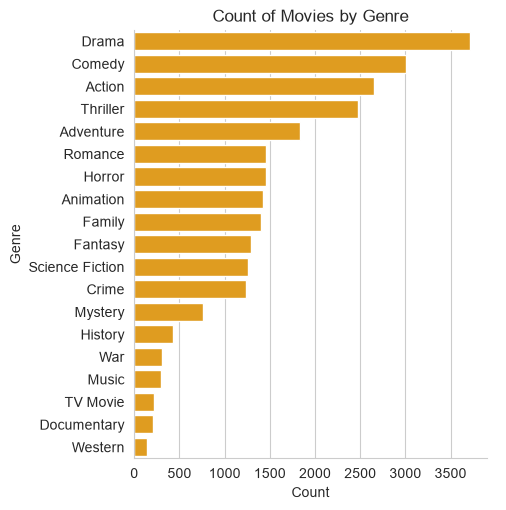

In [28]:
sns.catplot(y = 'Genre', 
            data = df, 
            kind = 'count', 
            color = 'orange', 
            order = df['Genre'].value_counts().index)

plt.title('Count of Movies by Genre')
plt.xlabel('Count')
plt.ylabel('Genre')

plt.show()

##### Highest votes in vote_average column

In [29]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


In [30]:
df['Vote_Average'].value_counts()

Vote_Average
Average        6613
Popular        6520
Below_Avg      6348
Not_Popular    6071
Name: count, dtype: int64

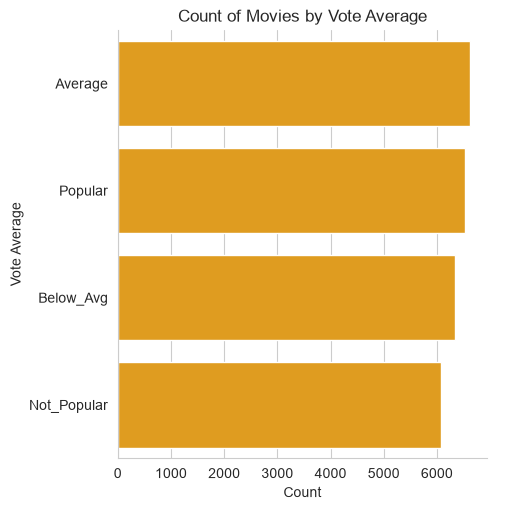

In [31]:
#As we will plot category we will use catplot function of seabor library.
sns.catplot(y = 'Vote_Average',
            data = df,
            kind = 'count',
            color = 'orange',
            order = df['Vote_Average'].value_counts().index)

plt.title('Count of Movies by Vote Average')
plt.xlabel('Count')
plt.ylabel('Vote Average')

plt.show()

##### Movie with highest popularity and its genre

In [32]:
df.head(5)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


In [33]:
df[df['Popularity'] == df['Popularity'].max()].head(5)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction


##### Movie with lowest popularity

In [34]:
df.head(5)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


In [35]:
df[df['Popularity'] == df['Popularity'].min()].head(5)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,Average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,Average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,Average,History
25549,1984,Threads,13.354,186,Popular,War
25550,1984,Threads,13.354,186,Popular,Drama


##### Year with most movies filmmed

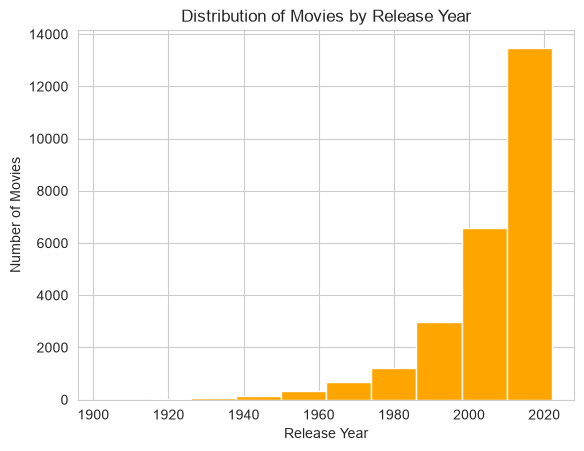

In [36]:
df['Release_Date'].hist(color='orange')

plt.title('Distribution of Movies by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')

plt.show()

In [37]:
#Conclusion and general summary of the analysis:
#1. The dataset contains information about movies available on Netflix, including their genres, release dates, popularity, and average votes.
#2. The most common genres in the dataset are Drama, Comedy, and Action, while the least common genres are Western, War, and Musical.
#3. The year with the most movies filmed is [2020].